### 🤖 Modelo de Risco de Defasagem

**Base:** `df_ml_pares.parquet` — gerado no `12_Feature_Engineering.ipynb`

**Objetivo:** Construir modelo preditivo que estime a probabilidade de um aluno entrar em defasagem (IAN < 10) no ano seguinte.

**Estratégia:**
1. Baseline (modelo simples para referência)
2. Modelo principal com tuning
3. Avaliação: ROC-AUC, Recall, Precision, Matriz de Confusão
4. Interpretabilidade: feature importance + análise de erros

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

VERSAO = 'v3'

df_pares = pd.read_parquet(f'../../../data/db/01_silver_processed/df_ml_pares_{VERSAO}.parquet')

print(f'Dataset: {df_pares.shape[0]} pares | {df_pares.shape[1]} colunas')

Dataset: 1369 pares | 29 colunas


In [53]:
df_pares.columns

Index(['RA', 'ano_atual', 'ano_proximo', 'target', 'IAN', 'IDA', 'IEG', 'IAA',
       'IPS', 'IPP', 'IPV', 'nivel', 'pedra', 'instituicao', 'ano_ingresso',
       'gap_iaa_ida', 'resiliencia', 'primeiro_ano', 'tipo_escola',
       'ips_no_piso', 'IDA_norm', 'IEG_norm', 'IAA_norm', 'IPS_norm',
       'IPP_norm', 'IPV_norm', 'nivel_num', 'pedra_num', 'features'],
      dtype='object')

### Preparação dos dados

In [54]:
# Features numéricas e categóricas
features = json.loads(df_pares['features'].iloc[0])

print(f'=== Features ===')
for f in features:
    print(f'|_  {f}')

=== Features ===
|_  IDA_norm
|_  IEG_norm
|_  IPS_norm
|_  IPP_norm
|_  IPV_norm
|_  IAN
|_  resiliencia
|_  primeiro_ano
|_  nivel_num
|_  tipo_escola


In [55]:
# Separação temporal
df_treino = df_pares[df_pares['ano_atual'] == 2022].copy()
df_teste = df_pares[df_pares['ano_atual'] == 2023].copy()

X_treino = df_treino[features]
y_treino = df_treino['target']
X_teste = df_teste[features]
y_teste = df_teste['target']

print(f'=== Dados ===')
print(f'  Treino: {X_treino.shape[0]} amostras, target={y_treino.mean()*100:.1f}% defasados')
print(f'  Teste:  {X_teste.shape[0]} amostras, target={y_teste.mean()*100:.1f}% defasados')

=== Dados ===
  Treino: 604 amostras, target=60.8% defasados
  Teste:  765 amostras, target=40.3% defasados


### Baseline + Modelos

In [56]:
# Encoding para categóricas (HistGradientBoosting aceita nulos nativamente)
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_treino_enc = X_treino.copy()
X_teste_enc = X_teste.copy()

RANDOM_STATE = 157

# --- Modelo 1: Baseline — Regressão Logística ---
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_treino_enc.fillna(-999), y_treino)
y_prob_lr = lr.predict_proba(X_teste_enc.fillna(-999))[:, 1]

# --- Modelo 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_treino_enc.fillna(-999), y_treino)
y_prob_rf = rf.predict_proba(X_teste_enc.fillna(-999))[:, 1]

# --- Modelo 3: HistGradientBoosting (aceita nulos nativamente) ---
hgb = HistGradientBoostingClassifier(
    max_iter=200, max_depth=6, learning_rate=0.1, random_state=RANDOM_STATE
)
hgb.fit(X_treino_enc, y_treino)
y_prob_hgb = hgb.predict_proba(X_teste_enc)[:, 1]

# --- Comparação ---
print('=== ROC-AUC no conjunto de teste (2023→2024) ===')
modelos = {
    'Logistic Regression': y_prob_lr,
    'Random Forest': y_prob_rf,
    'HistGradientBoosting': y_prob_hgb,
}

for nome, y_prob in modelos.items():
    auc = roc_auc_score(y_teste, y_prob)
    print(f'  {nome:30}: AUC = {auc:.4f}')

=== ROC-AUC no conjunto de teste (2023→2024) ===
  Logistic Regression           : AUC = 0.6521
  Random Forest                 : AUC = 0.7828
  HistGradientBoosting          : AUC = 0.8466


### Avaliação do melhor modelo

Melhor modelo: HistGradientBoosting
AUC: 0.8466

=== Classification Report (threshold=0.5) ===
              precision    recall  f1-score   support

    Adequado       0.88      0.64      0.74       457
    Defasado       0.62      0.87      0.72       308

    accuracy                           0.73       765
   macro avg       0.75      0.75      0.73       765
weighted avg       0.77      0.73      0.73       765



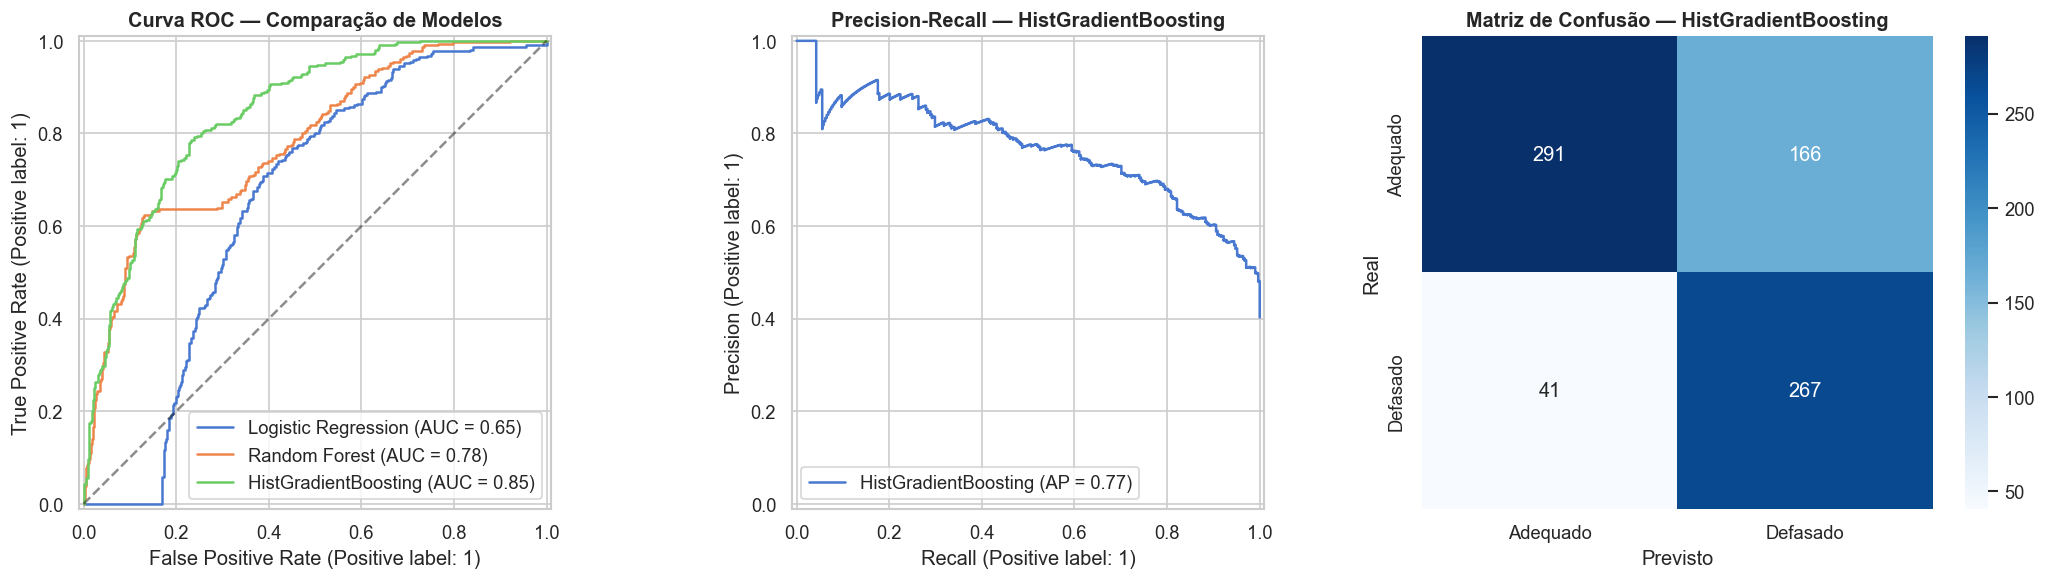

In [57]:
# Selecionar melhor modelo (baseado no AUC)
melhor_nome = max(modelos.items(), key=lambda x: roc_auc_score(y_teste, x[1]))[0]
y_prob_melhor = modelos[melhor_nome]

print(f'Melhor modelo: {melhor_nome}')
print(f'AUC: {roc_auc_score(y_teste, y_prob_melhor):.4f}')

# Threshold: usar 0.5 como padrão, depois ajustar se necessário
y_pred = (y_prob_melhor >= 0.5).astype(int)

print(f'\n=== Classification Report (threshold=0.5) ===')
print(classification_report(y_teste, y_pred, target_names=['Adequado', 'Defasado']))

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC Curve
for nome, y_prob in modelos.items():
    RocCurveDisplay.from_predictions(y_teste, y_prob, ax=axes[0], name=nome)
axes[0].set_title('Curva ROC — Comparação de Modelos', fontweight='bold')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)

# Precision-Recall Curve (melhor modelo)
PrecisionRecallDisplay.from_predictions(y_teste, y_prob_melhor, ax=axes[1], name=melhor_nome)
axes[1].set_title(f'Precision-Recall — {melhor_nome}', fontweight='bold')

# Matriz de confusão
cm = confusion_matrix(y_teste, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Adequado', 'Defasado'], yticklabels=['Adequado', 'Defasado'])
axes[2].set_title(f'Matriz de Confusão — {melhor_nome}', fontweight='bold')
axes[2].set_xlabel('Previsto')
axes[2].set_ylabel('Real')

plt.tight_layout()
plt.show()

### Feature Importance

In [ ]:
if melhor_nome == 'HistGradientBoosting':
    modelo_melhor = hgb
    X_eval = X_teste_enc
elif melhor_nome == 'Random Forest':
    modelo_melhor = rf
    X_eval = X_teste_enc.fillna(-999)
else:
    modelo_melhor = lr
    X_eval = X_teste_enc.fillna(-999)

result = permutation_importance(modelo_melhor, X_eval, y_teste, 
                                 n_repeats=10, random_state=RANDOM_STATE, scoring='roc_auc')

feat_imp = pd.Series(result.importances_mean, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax, color=['#e74c3c' if v > feat_imp.median() else '#3498db' for v in feat_imp.values])
ax.set_title(f'Feature Importance (Permutation) — {melhor_nome}', fontweight='bold')
ax.set_xlabel('Importância (queda no AUC ao permutar)')

plt.tight_layout()
plt.show()

print('=== Ranking de features ===')
for feat, imp in feat_imp.sort_values(ascending=False).items():
    print(f'|_  {feat:20}: {imp:.4f}')

### Análise de probabilidades

=== Faixas de risco ===
               n  pct_defasado
faixa_risco                   
Muito baixo  239           6.7
Baixo         63          20.6
Moderado      68          38.2
Alto          85          38.8
Muito alto   310          71.0


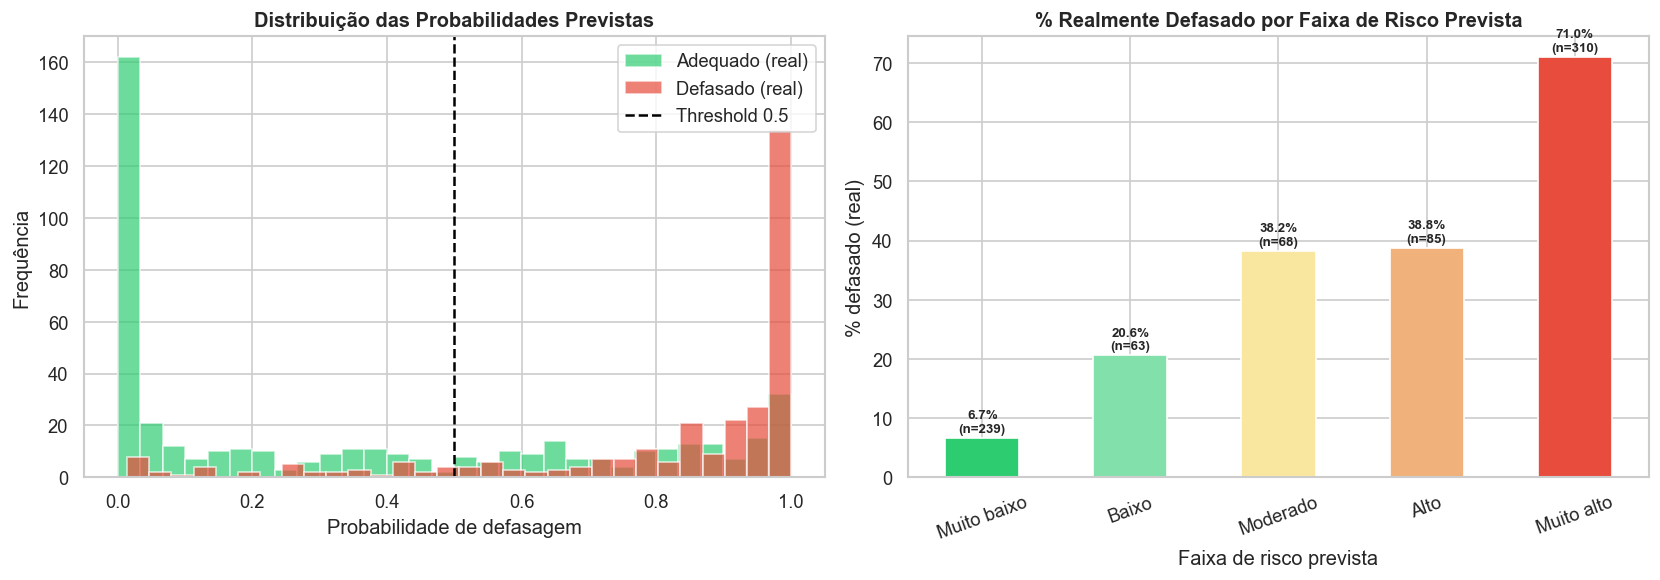

In [ ]:
# Distribuição das probabilidades previstas
df_teste_result = df_teste[['RA', 'ano_atual', 'target']].copy()
df_teste_result['prob_defasagem'] = y_prob_melhor

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma das probabilidades
axes[0].hist(df_teste_result[df_teste_result['target'] == 0]['prob_defasagem'],
             bins=30, alpha=0.7, label='Adequado (real)', color='#2ecc71')
axes[0].hist(df_teste_result[df_teste_result['target'] == 1]['prob_defasagem'],
             bins=30, alpha=0.7, label='Defasado (real)', color='#e74c3c')
axes[0].axvline(0.5, color='black', linestyle='--', label='Threshold 0.5')
axes[0].set_title('Distribuição das Probabilidades Previstas', fontweight='bold')
axes[0].set_xlabel('Probabilidade de defasagem')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Faixas de risco
df_teste_result['faixa_risco'] = pd.cut(df_teste_result['prob_defasagem'],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=['Muito baixo', 'Baixo', 'Moderado', 'Alto', 'Muito alto'])

faixa_stats = df_teste_result.groupby('faixa_risco').agg(
    n=('target', 'count'),
    pct_defasado=('target', 'mean')
).round(3)
faixa_stats['pct_defasado'] = (faixa_stats['pct_defasado'] * 100).round(1)

print('=== Faixas de risco ===')
print(faixa_stats.to_string())

cores_faixa = ['#2ecc71', '#82e0aa', '#f9e79f', '#f0b27a', '#e74c3c']
faixa_stats['pct_defasado'].plot(kind='bar', ax=axes[1], color=cores_faixa)
axes[1].set_title('% Realmente Defasado por Faixa de Risco Prevista', fontweight='bold')
axes[1].set_ylabel('% defasado (real)')
axes[1].set_xlabel('Faixa de risco prevista')
axes[1].tick_params(axis='x', rotation=20)

for i, (faixa, row) in enumerate(faixa_stats.iterrows()):
    axes[1].text(i, row['pct_defasado'] + 1, f'{row["pct_defasado"]:.1f}%\n(n={int(row["n"])})',
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

### 💡 Insights

- Ao remover features desnecessárias, o modelo respondeu melhor:
  - AUC: 8466 vs 0.8396
  - Recall: 87% vs 82%
  - Precision: 62% vs 61%
  - 
- 